In [1]:
import pandas as pd 
import numpy as np 
import statistics as st 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set(rc={"figure.figsize":(15, 6)})
pd.pandas.set_option("display.max_columns", None)

In [2]:
data=pd.read_csv("adult.csv")

In [3]:
data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
data.shape

(32561, 15)

In [5]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [6]:
data.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
#check null values in our complete dataset
data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [9]:
#check all duplicate values in dataset
data.duplicated().sum()

np.int64(24)

In [10]:
#drop duplicate values from data
data.drop_duplicates(inplace=True)

In [11]:
data.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [12]:
# separate categorical and numerical features
categorical_features = data.select_dtypes(include="object").columns
numerical_features = data.select_dtypes(exclude="object").columns

In [13]:
categorical_features

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [14]:
numerical_features

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

In [15]:
data["workclass"].value_counts()

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [16]:
#fetch the unique value from categorical data
for i in categorical_features:
    print(i, data[i].unique())

    print()
    print()

workclass [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 nan ' Self-emp-inc' ' Without-pay' ' Never-worked']


education [' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']


marital_status [' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']


occupation [' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' nan
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv']


relationship [' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']


race [' White' ' Black' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo' ' Other']


sex [' Male' ' Female']


native_country [' United-States' ' Cuba' ' Jamaica

In [17]:
#remove "?" an replace it with mode
data["workclass"]= data["workclass"].replace("?", "Private")
data["occupation"]= data["occupation"].replace("?", "Prof-specialty")
data["native_country"]= data["native_country"].replace("?", "United-States")

DATA VISUALIZATION 

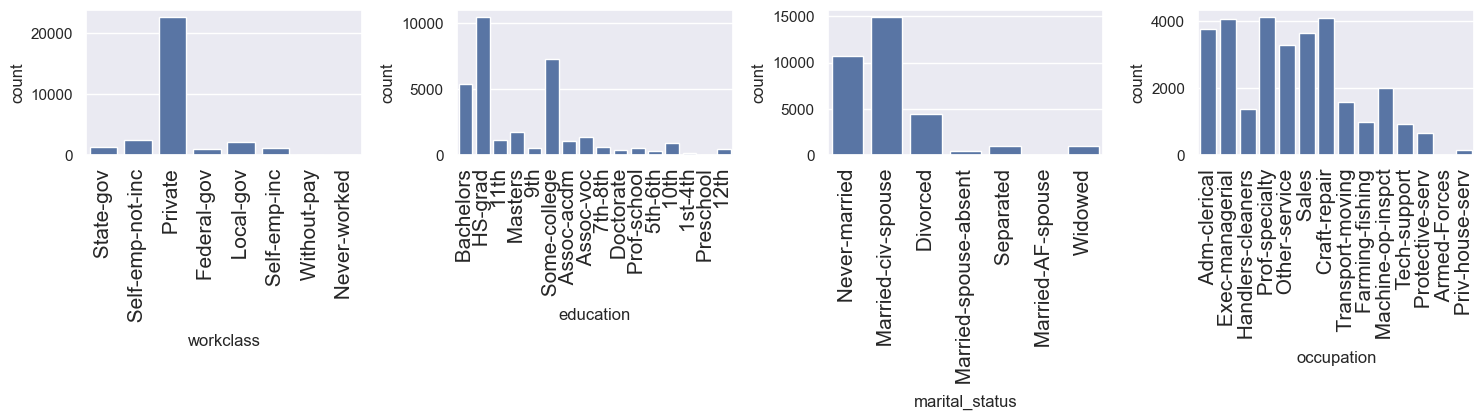

In [18]:
plt.style.use("fivethirtyeight")
sns.set(rc={"figure.figsize":(15,6)})

column1 = ["workclass", "education", "marital_status", "occupation"]

for i in range(0, len(column1)):
    plt.subplot(2,4,i+1)
    sns.countplot(x=data[column1[i]])
    plt.xticks(size=15, rotation=90)
    plt.tight_layout()

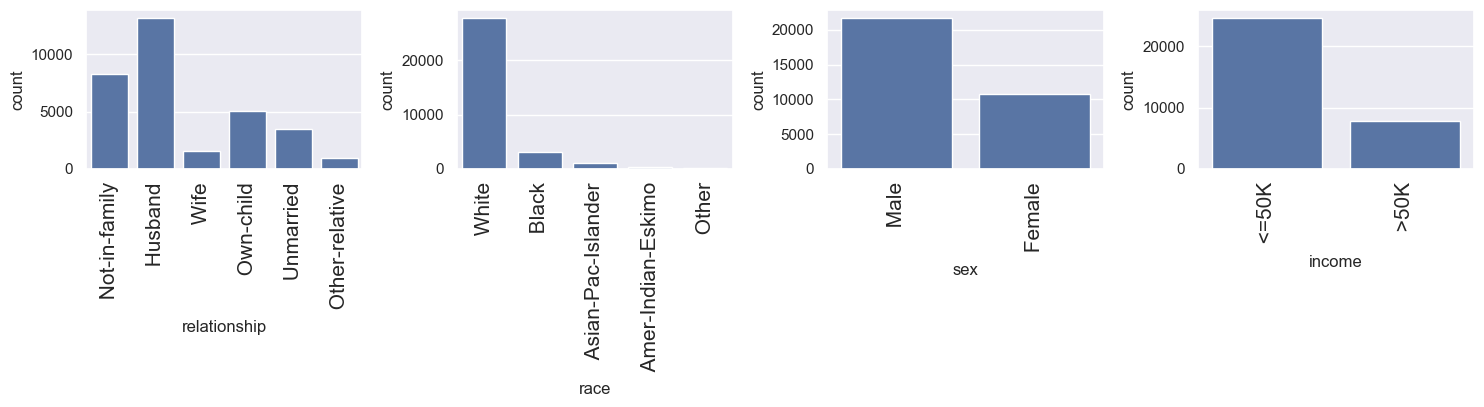

In [19]:
column2 = ["relationship", "race", "sex", "income"]

for i in range(0, len(column2)):
    plt.subplot(2,4,i+1)
    sns.countplot(x=data[column2[i]])
    plt.xticks(size=15, rotation=90)
    plt.tight_layout()

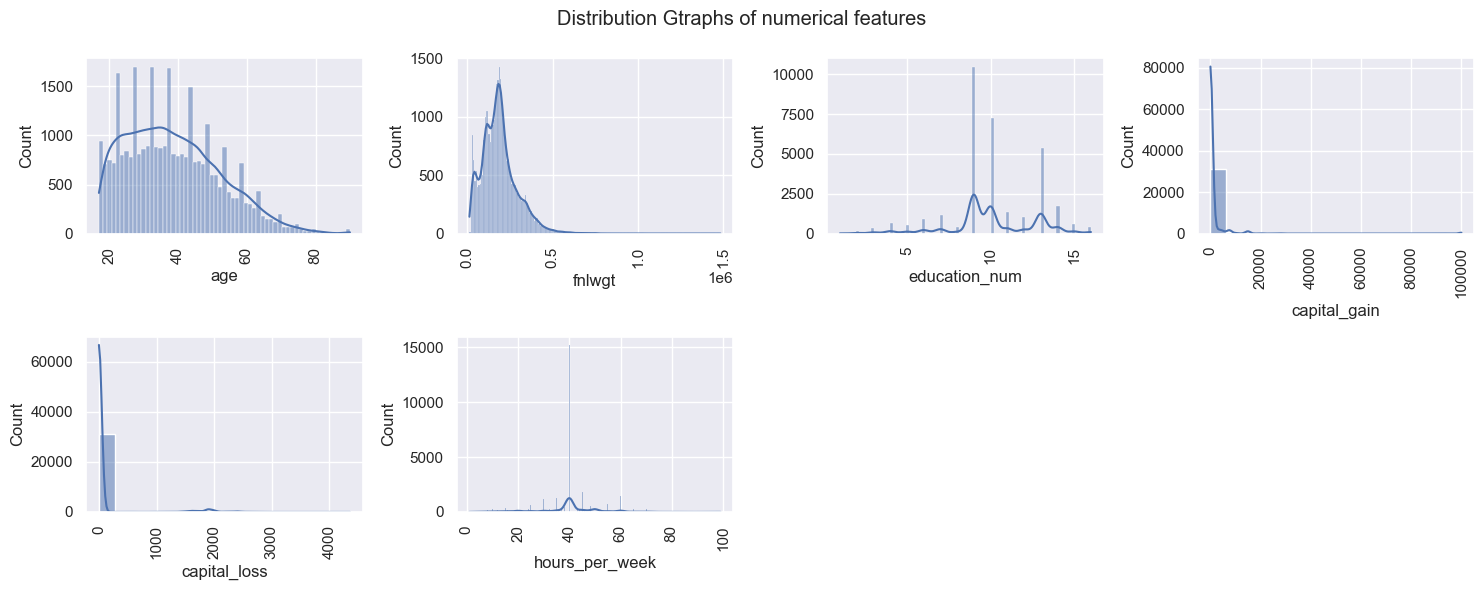

In [20]:
plt.suptitle("Distribution Gtraphs of numerical features")

for i in range(len(numerical_features)):
    plt.subplot(2, 4, i + 1)  # lowercase 'subplot'
    sns.histplot(data[numerical_features[i]], kde=True)  # distplot is deprecated
    plt.xticks(rotation=90)
    plt.tight_layout()

plt.show()

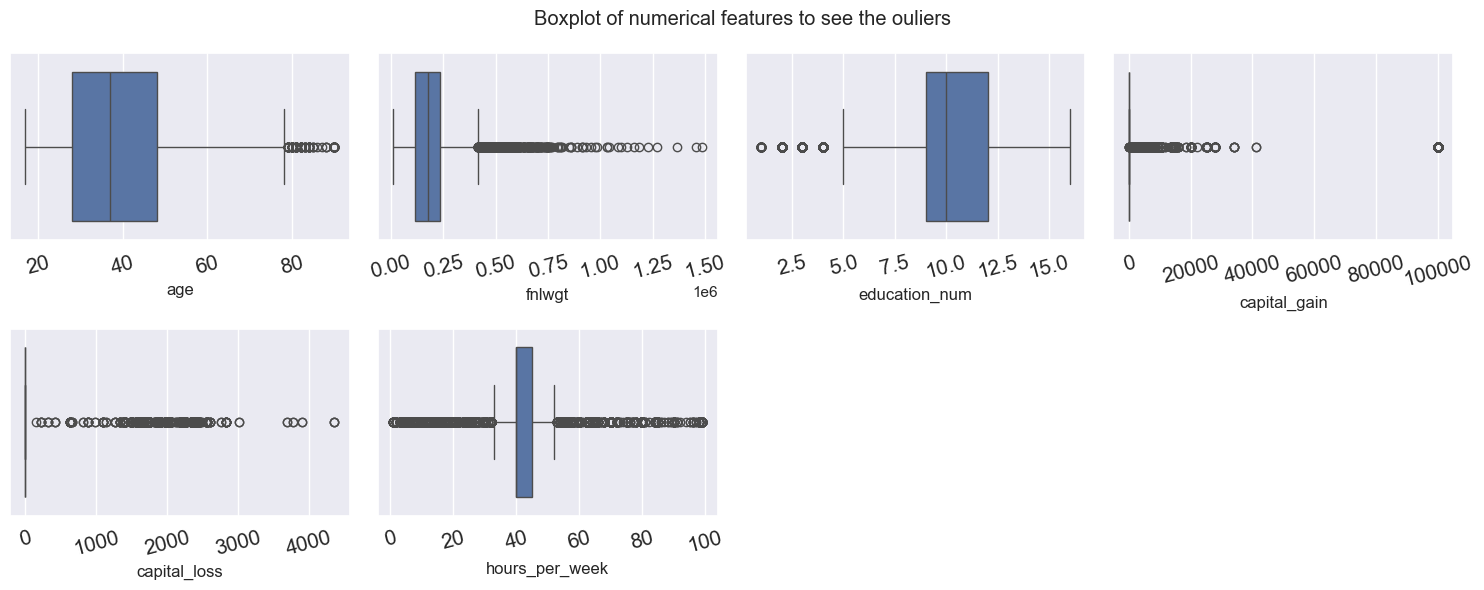

In [21]:
plt.suptitle("Boxplot of numerical features to see the ouliers")
for i in range(0, len(numerical_features)):
    plt.subplot(2,4,i+1)
    sns.boxplot(x=data[numerical_features[i]])
    plt.xticks(size=15, rotation=15)
    plt.tight_layout()

<Axes: xlabel='income'>

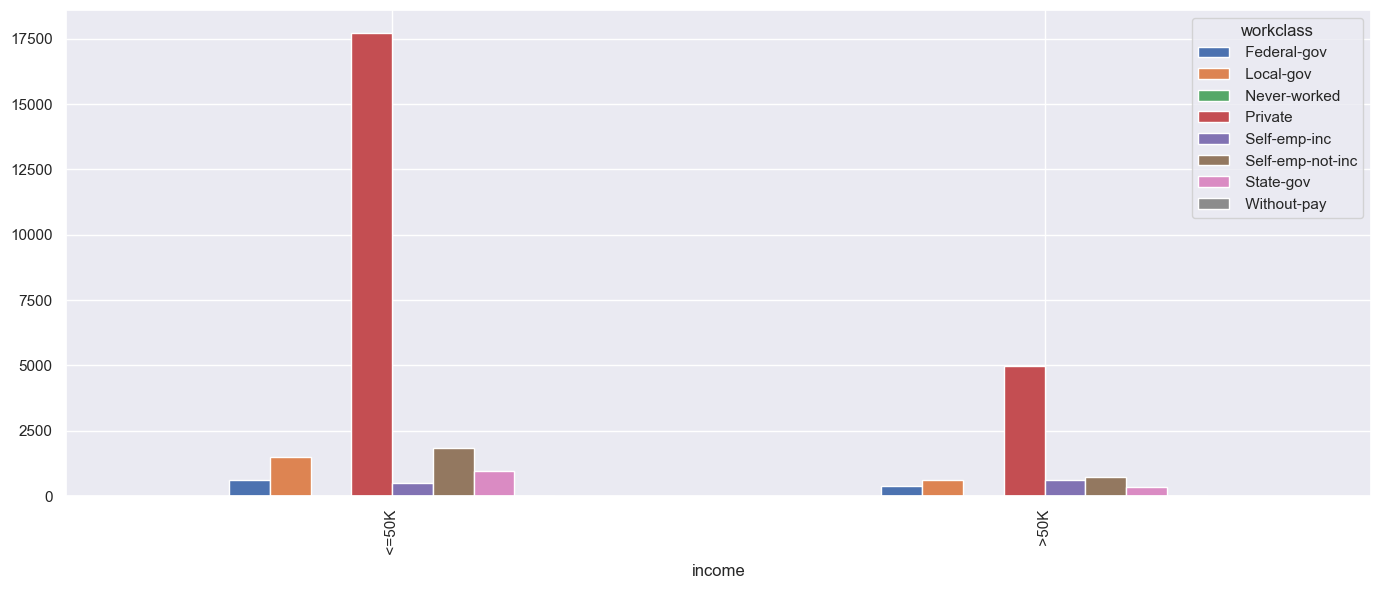

In [22]:
salary = pd.crosstab(data['income'], data['workclass'])
salary.plot(kind='bar')

<Axes: xlabel='income'>

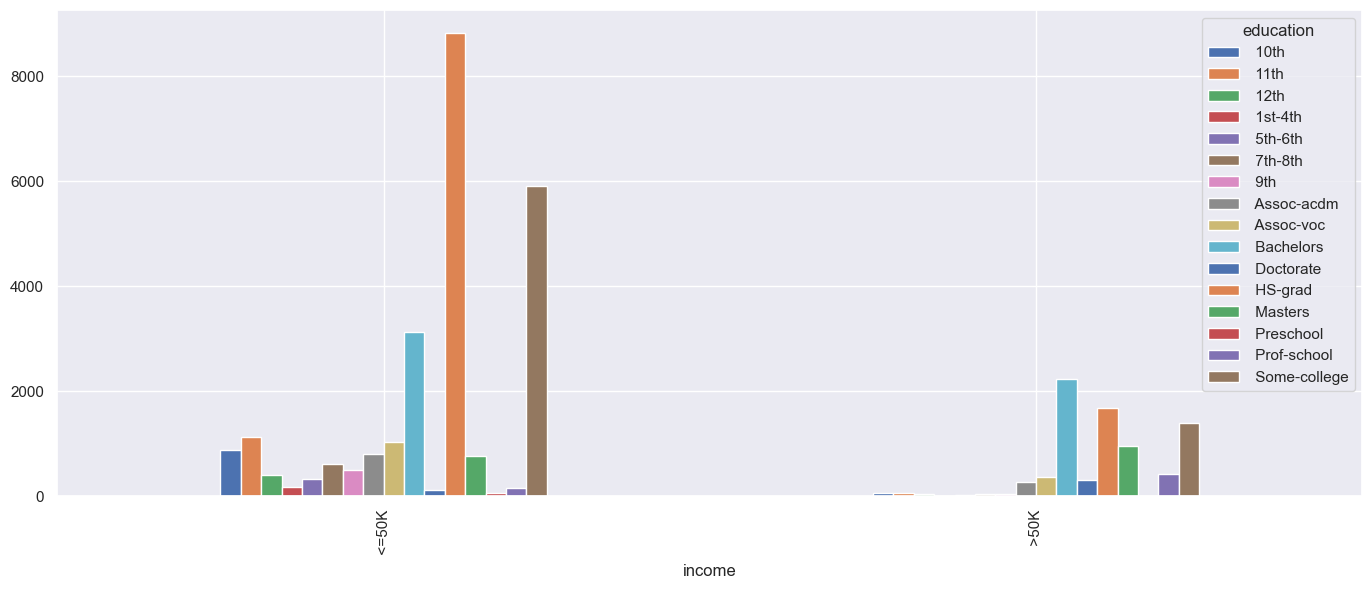

In [23]:
salary = pd.crosstab(data['income'], data['education'])
salary.plot(kind='bar')

<Axes: xlabel='income'>

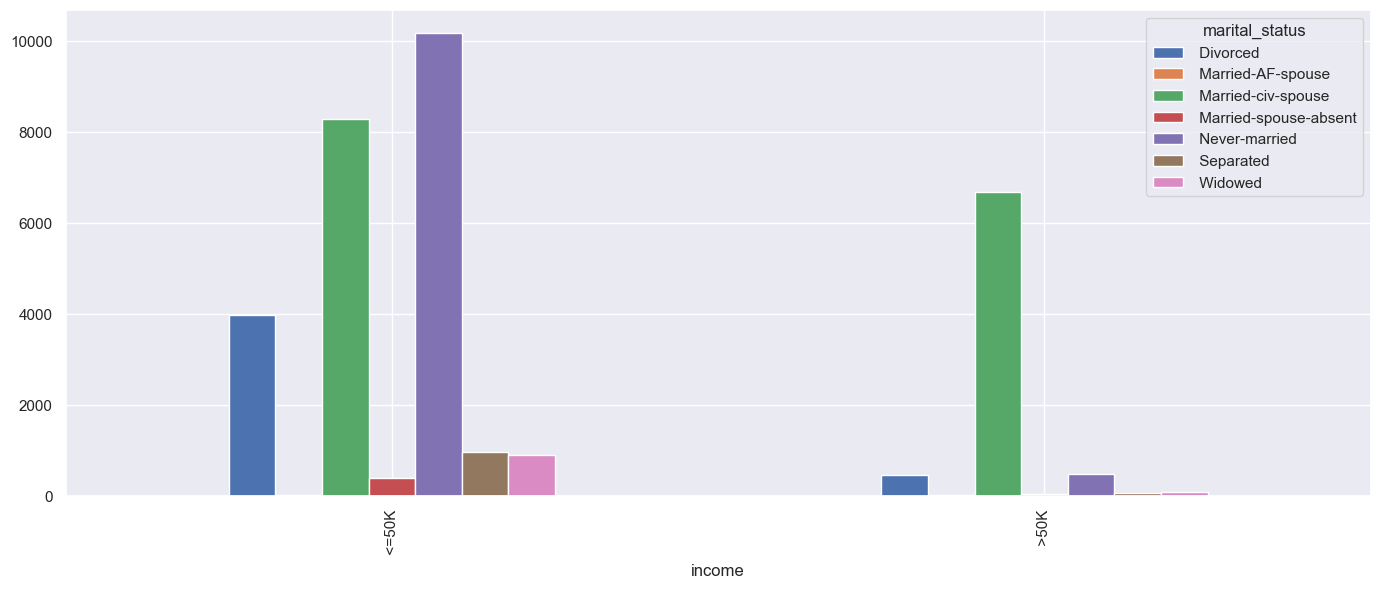

In [24]:
salary = pd.crosstab(data['income'], data['marital_status'])
salary.plot(kind='bar')

<Axes: xlabel='income'>

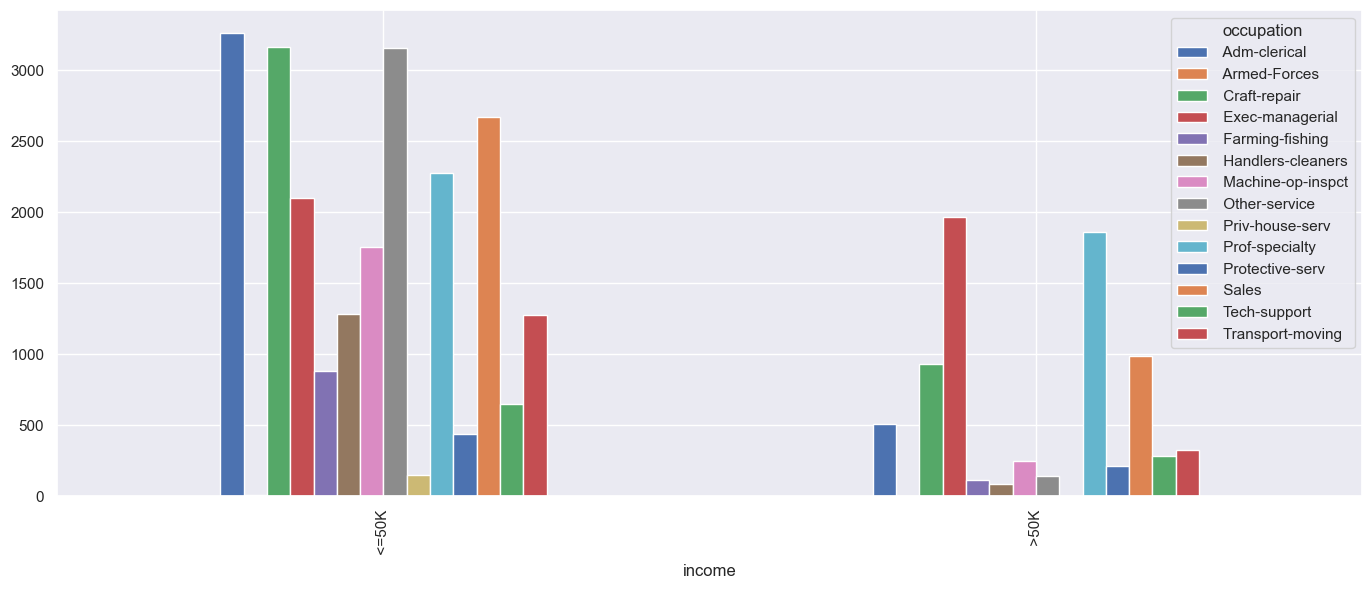

In [25]:
salary = pd.crosstab(data['income'], data['occupation'])
salary.plot(kind='bar')

In [26]:
from sklearn.preprocessing import LabelEncoder

#create a label Encoder object
le = LabelEncoder()

#defining the categorical features
categorical_features = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

#Loop through the categorical features and encode them
for feature in categorical_features:
    le.fit(data[feature])
    data[feature] = le.transform(data[feature])

In [27]:
data['income'] = data['income'].map({'<=50k':0, '>50k':1})

<Axes: >

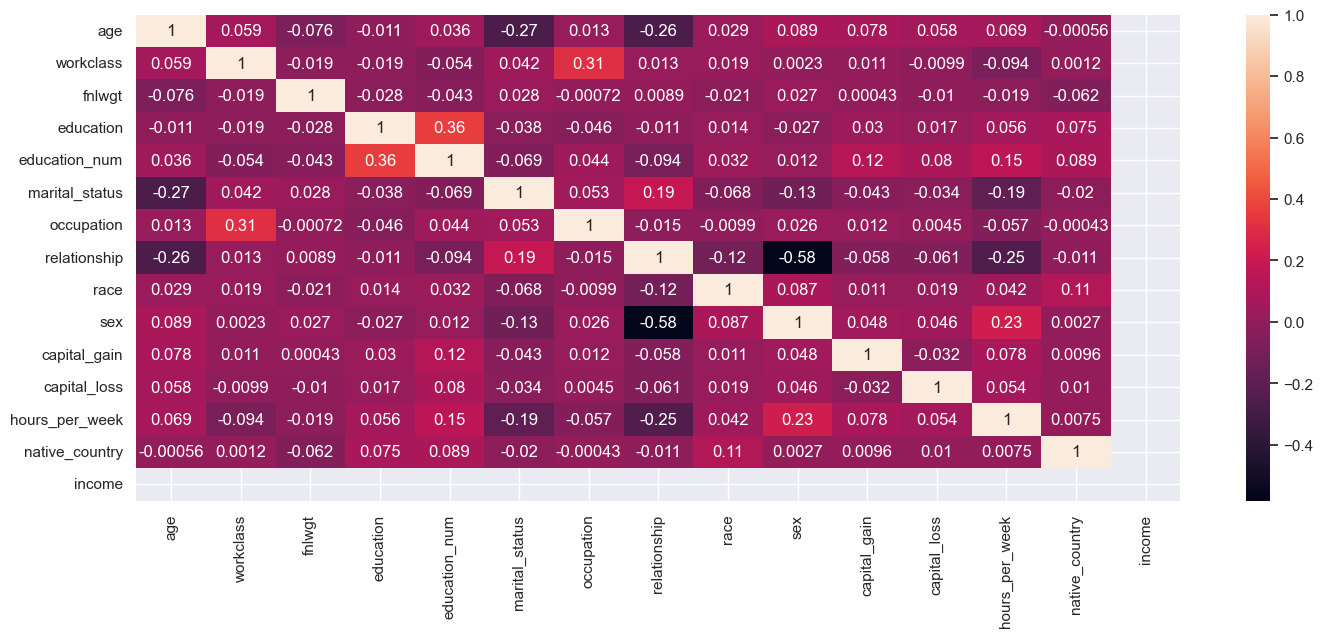

In [28]:
sns.heatmap(data.corr(), annot = True)

In [29]:
data['income'].value_counts()

Series([], Name: count, dtype: int64)

In [30]:
#droping enducation_num column becaouse we have education ordinal ecorded one
data.drop(['education', 'fnlwgt', 'native_country'], axis=1, inplace=True)

In [31]:
data.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income
0,39,6,13,4,0,1,4,1,2174,0,40,NaN
1,50,5,13,2,3,0,4,1,0,0,13,NaN
2,38,3,9,0,5,1,4,1,0,0,40,NaN
3,53,3,7,2,5,0,2,1,0,0,40,NaN
4,28,3,13,2,9,5,2,0,0,0,40,NaN


In [32]:
data.to_csv("cleaneddata.csv", index=False)

MODEL TRAINING 

In [33]:
data.shape

(32537, 12)

In [34]:
#seperate independent and dependent variable
x = data.drop("income", axis =1)
y = data['income']

In [35]:
categorical_features = x.select_dtypes(include='object').columns
numerical_features = x.select_dtypes(exclude='object').columns

print(categorical_features)
print(numerical_features)

Index([], dtype='object')
Index(['age', 'workclass', 'education_num', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
#pipeline
from sklearn.pipeline import  Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

In [37]:
num_pipeline = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler())
    ]
) #to standardize the data values into a standard formte

cat_pipeline = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("scaler", StandardScaler())
    ]
)

In [40]:
rf = RandomForestClassifier()

In [41]:
param_grid = {
    'class_weight': ['balanced'],
    'n_estimators': [20, 50, 30],
    'max_depth': [10, 8, 5],
    'min_samples_split': [2, 5, 10]
}

#apply transform to perticular column
preprocessor = ColumnTransformer([
    ("num_pipeline", num_pipeline, numerical_features)
])

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=1)

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [44]:
def performance_metrices(test, predict):
    confusionmetrix = print(f"CONFUSION_METRIX: {confusion_matrix(test, predict)}")

    precision = print(f"PRECISION_SCORE: {precision_score(test, predict)}")

    recall = print(f"F1_SCORE: {f1_score(test, predict)}")

    f1score = print(f"F1_SCORE: {f1_score(test, predict)}")

    accuracyscore = print(f"ACCURACY_SCORE: {accuracy_score(test, predict)}")

    return confusionmetrix, precision, recall, f1score, accuracyscore

In [45]:
lr = LogisticRegression()

In [46]:
param = {
    'solver': ['liblinear'],  # supports both
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced']
}

In [47]:
grid = GridSearchCV(estimator=lr, param_grid=param, cv=2,  n_jobs=-1, verbose=3)

In [48]:
grid.fit(x_train, y_train)

ValueError: Input y contains NaN.

In [ ]:
grid.best_params_

In [ ]:
grid.score(x_train, y_train)

In [ ]:
y_pred = grid.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred)

In [ ]:
dr = DecisionTreeClassifier()

In [ ]:
param = {
    'class_weight': ['balanced'],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [3,4,5,6],
    'min_samples_split': [2,3,4,5],
    'min_samples_leaf': [1,2,3],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [ ]:
grid_search = GridSearchCV(estimators=dr, param_grid=param_grid, cv=5, scoring='accuracy')

In [ ]:
grid_search.fit(x_train, y_train)

In [ ]:
grid_search.best_params_

In [ ]:
grid_search.score(x_train,y_train)

In [ ]:
y_pred = grid_search.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred)

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
rf = RandomForestClassifier()

In [ ]:
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy')

In [ ]:
grid_search.fit(x_train, y_train)

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
grid_search.best_params_

In [ ]:
grid_search.score(x_train, y_train)

In [ ]:
y_pred = gird_search.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred)

In [ ]:
print(classification_report(y_test, y_pred))